# Video Analysis — 10 November 2025 (`GX010063_2025Nov10.MP4`)

Detects and quantifies blue-light pulses as contours in the Star Trails timelapse video recorded on **10 November 2025**.

**Pipeline:**
1. Set `video_name` and load/save per-video parameters from `data/config/`
2. Run `scripts/analyze_streaks.py` over all frames → `data/processed/<stem>_streaks.csv`
3. Interactively preview the top-contour frames to verify detection settings
4. Draw ROIs interactively on the best frame → `data/config/<stem>_rois.json`
5. Apply ROI assignment and a persistence filter to remove static/long-duration artifacts
6. Plot detection rates by region over clock time and save figures to `figures/`

**Key outputs** (all keyed by video stem):
- `data/processed/<stem>_streaks.csv` — raw per-frame detections
- `data/processed/<stem>_streaks_in_roi_filtered.csv` — ROI- and persistence-filtered detections
- `data/config/<stem>_analysis.json` — saved analysis parameters
- `data/config/<stem>_rois.json` — saved ROI definitions
- `figures/<stem>_detections_in_roi_*.png` — detection rate plots

> **Videos are not stored in this repository.** Run `00_download_videos_from_dryad.ipynb` to populate `video/` before executing this notebook.

In [1]:
# Set project paths — run this cell first before any other
from pathlib import Path

ROOT          = Path('..').resolve()  # repository root (this notebook lives in notebooks/)
DATA_DIR      = ROOT / 'data'
FIGURES_DIR   = ROOT / 'figures' / 'notebook'
VIDEO_DIR     = ROOT / 'video'
SCRIPT_DIR    = ROOT / 'scripts'
CONFIG_DIR    = DATA_DIR / 'config'
PROCESSED_DIR = DATA_DIR / 'processed'

for p in [DATA_DIR, FIGURES_DIR, VIDEO_DIR, CONFIG_DIR, PROCESSED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('ROOT          =', ROOT)
print('DATA_DIR      =', DATA_DIR)
print('FIGURES_DIR   =', FIGURES_DIR)
print('VIDEO_DIR     =', VIDEO_DIR)
print('CONFIG_DIR    =', CONFIG_DIR)
print('PROCESSED_DIR =', PROCESSED_DIR)

ROOT          = /Users/oakley/Documents/GitHub/signal_respirometry
DATA_DIR      = /Users/oakley/Documents/GitHub/signal_respirometry/data
FIGURES_DIR   = /Users/oakley/Documents/GitHub/signal_respirometry/figures
VIDEO_DIR     = /Users/oakley/Documents/GitHub/signal_respirometry/video
CONFIG_DIR    = /Users/oakley/Documents/GitHub/signal_respirometry/data/config
PROCESSED_DIR = /Users/oakley/Documents/GitHub/signal_respirometry/data/processed


## Detection method

Blue-light pulses are detected by thresholding the blue channel (optionally using B − G to suppress non-blue signal), finding contours above a minimum area, and recording their centroid and bounding box per frame to CSV. Parameters (threshold, scale, blur, etc.) are saved per-video to `data/config/` as JSON so they can be reloaded without re-running interactively.

## Per-video workflow

Run the cells below **in order**:
1. Set `video_name` and `rerun_roi` (next cell)
2. Load saved parameters for this video (or accept defaults)
3. Optionally edit and save updated parameters
4. Run the contour extractor to produce the detections CSV
5. Preview top frames interactively to verify threshold/scale settings
6. Draw ROIs interactively (skipped automatically if a saved ROI JSON already exists)
7. Set `start_clock` and `moonrise_offset` for the x-axis and annotation
8. Apply ROI + persistence filter; export filtered CSV; plot detection rates
9. Run the visual overlay viewer for a final sanity check

> To force re-drawing ROIs, set `rerun_roi = True` in cell 2.

In [2]:
video_name = "GX010063_2025Nov10.MP4"

# Toggle ROI re-selection when running end-to-end
rerun_roi = False  # False = reuse existing ROI JSON if present; True = force interactive ROI selection
print('rerun_roi =', rerun_roi)

rerun_roi = False


In [3]:
# Load saved analysis parameters for the current video (or accept defaults)
import json

# List available videos in VIDEO_DIR
videos = sorted([p.name for p in VIDEO_DIR.iterdir() if p.is_file() and p.suffix.lower() in {'.mp4','.mov','.mkv','.avi','.m4v'}])
try:
    video_name
except NameError:
    video_name = videos[0] if videos else 'GX010063.MP4'

print('Current video_name =', video_name)

# Try to load saved params for this video (if present)
params_path = CONFIG_DIR / f"{Path(video_name).stem}_analysis.json"
if params_path.exists():
    with open(params_path, 'r') as f:
        saved = json.load(f)
    # Apply known params if defined in saved JSON
    analyze_scale = float(saved.get('analyze_scale', globals().get('analyze_scale', 0.5)))
    blue_thresh   = saved.get('blue_thresh', globals().get('blue_thresh', 60))
    blur_ksize    = int(saved.get('blur_ksize', globals().get('blur_ksize', 0)))
    min_area      = float(saved.get('min_area', globals().get('min_area', 1.5)))
    use_bminusg   = bool(saved.get('use_bminusg', globals().get('use_bminusg', True)))
    seconds_per_frame = float(saved.get('seconds_per_frame', globals().get('seconds_per_frame', 30.0)))
    # Persistence filter params
    enable_persistence_filter = bool(saved.get('enable_persistence_filter', globals().get('enable_persistence_filter', True)))
    persistence_link_radius_px = float(saved.get('persistence_link_radius_px', globals().get('persistence_link_radius_px', 8.0)))
    max_track_duration_s = float(saved.get('max_track_duration_s', globals().get('max_track_duration_s', 50.0)))
    print('Loaded saved parameters from', params_path)
else:
    print('No saved parameters found for this video; using current defaults.')

# Show the parameters currently in effect (using variables if set, else defaults)
effective = {
    'analyze_scale': float(globals().get('analyze_scale', 0.5)),
    'blue_thresh': globals().get('blue_thresh', 60),
    'blur_ksize': int(globals().get('blur_ksize', 0)),
    'min_area': float(globals().get('min_area', 1.5)),
    'use_bminusg': bool(globals().get('use_bminusg', True)),
    'seconds_per_frame': float(globals().get('seconds_per_frame', 30.0)),
    # Persistence filter params
    'enable_persistence_filter': bool(globals().get('enable_persistence_filter', False)),
    'persistence_link_radius_px': float(globals().get('persistence_link_radius_px', 8.0)),
    'max_track_duration_s': float(globals().get('max_track_duration_s', 50.0)),
}
print('Using parameters:', json.dumps(effective, indent=2))

Current video_name = GX010063_2025Nov10.MP4
Loaded saved parameters from /Users/oakley/Documents/GitHub/signal_respirometry/data/config/GX010063_2025Nov10_analysis.json
Using parameters: {
  "analyze_scale": 0.5,
  "blue_thresh": 40,
  "blur_ksize": 0,
  "min_area": 1.5,
  "use_bminusg": true,
  "seconds_per_frame": 30.0,
  "enable_persistence_filter": true,
  "persistence_link_radius_px": 8.0,
  "max_track_duration_s": 190.0
}


In [ ]:
# Save current parameters for this video (does not overwrite an existing file unless forced)
import json

# Base parameters come from currently defined globals (e.g., loaded from file) or sensible defaults
gs = globals()
base_params = {
    'analyze_scale': float(gs.get('analyze_scale', 0.5)),
    'blue_thresh': gs.get('blue_thresh', 60),  # may be None to use Otsu
    'blur_ksize': int(gs.get('blur_ksize', 0)),
    'min_area': float(gs.get('min_area', 1.5)),
    'use_bminusg': bool(gs.get('use_bminusg', True)),
    'seconds_per_frame': float(gs.get('seconds_per_frame', 30.0)),
    # Persistence filtering parameters
    'enable_persistence_filter': bool(gs.get('enable_persistence_filter', True)),
    'persistence_link_radius_px': float(gs.get('persistence_link_radius_px', 8.0)),
    'max_track_duration_s': float(gs.get('max_track_duration_s', 50.0)),
}

# Optional overrides (examples). Keep keys commented out to let JSON/default values drive parameters.
overrides = {
    # 'seconds_per_frame': 30.0,
    # 'blue_thresh': 40,           # or None for Otsu
    # 'use_bminusg': False,
    # 'analyze_scale': 0.5,
    # 'blur_ksize': 3,
    # 'min_area': 2.0,
    # 'enable_persistence_filter': True,
    # 'persistence_link_radius_px': 8.0,
    # 'max_track_duration_s': 50.0,
}

# Set to True to overwrite an existing params file
try:
    force_overwrite
except NameError:
    force_overwrite = False

allowed_keys = set(base_params.keys())
unknown = set(overrides.keys()) - allowed_keys
if unknown:
    print('Warning: ignoring unknown keys in overrides:', sorted(unknown))
    for k in sorted(unknown):
        overrides.pop(k, None)

def _coerce(key, value):
    if key == 'blue_thresh':
        return int(value) if value is not None else None
    if key in ('blur_ksize',):
        return int(value)
    if key in ('analyze_scale', 'min_area', 'seconds_per_frame', 'persistence_link_radius_px', 'max_track_duration_s'):
        return float(value)
    if key in ('use_bminusg', 'enable_persistence_filter'):
        return bool(value)
    return value

params = dict(base_params)
for k, v in overrides.items():
    params[k] = _coerce(k, v)

params_path = CONFIG_DIR / f"{Path(video_name).stem}_analysis.json"
if params_path.exists() and not force_overwrite:
    print('Parameters file already exists:', params_path)
    print('Not overwriting. Set force_overwrite=True to replace it.')
else:
    with open(params_path, 'w') as f:
        json.dump(params, f, indent=2)
    print('Saved parameters to', params_path)
    print('Parameters written:', json.dumps(params, indent=2))
    # Update globals so subsequent cells use the newly saved values immediately
    for k, v in params.items():
        globals()[k] = v

Saved parameters to /Users/oakley/Documents/GitHub/signal_respirometry/data/config/GX010063_2025Nov10_analysis.json
Parameters written: {
  "analyze_scale": 0.5,
  "blue_thresh": 40,
  "blur_ksize": 0,
  "min_area": 1.5,
  "use_bminusg": true,
  "seconds_per_frame": 30.0,
  "enable_persistence_filter": true,
  "persistence_link_radius_px": 8.0,
  "max_track_duration_s": 190.0
}


In [5]:
# Extract all contours across the entire video and find the best frame for ROI selection
import sys, subprocess, io
import pandas as pd

# Ensure video_name has been set (run the path-setup and video-name cells first)
try:
    video_name
except NameError:
    raise RuntimeError("video_name is not set. Run the video-name cell first.")

# Paths
an_script = SCRIPT_DIR / 'analyze_streaks.py'
if not an_script.exists():
    raise FileNotFoundError(f"Analyzer script not found: {an_script}")

video_path = VIDEO_DIR / video_name
if not video_path.exists():
    raise FileNotFoundError(f"Video not found: {video_path}")

csv_path  = PROCESSED_DIR / f"{Path(video_name).stem}_streaks.csv"
mask_path = PROCESSED_DIR / f"{Path(video_name).stem}_hotmask.png"

# Run analyzer over the entire video
cmd = [
    sys.executable,
    str(an_script),
    '--video', str(video_path),
    '--output', str(csv_path),
    '--scale', str(analyze_scale),
    '--blur-ksize', str(blur_ksize),
    '--min-area', str(min_area),
    '--seconds-per-frame', str(seconds_per_frame),
]
if use_bminusg:
    cmd += ['--use-bminusg']
if blue_thresh is not None:
    cmd += ['--blue-thresh', str(int(blue_thresh))]
if mask_path.exists():
    cmd += ['--mask-in', str(mask_path)]
print('Command:', ' '.join(cmd))
ret = subprocess.run(cmd, capture_output=True, text=True)
print(ret.stdout)
if ret.stderr:
    print('stderr:\n', ret.stderr)
print('Wrote detections to:', csv_path)

# Load CSV (skip metadata preamble) and compute best frame (most detections)
with open(csv_path, 'r') as f:
    lines = f.readlines()
header_idx = 0
for i, line in enumerate(lines[:100]):
    if line.lower().startswith('frame,'):
        header_idx = i
        break

df = pd.read_csv(io.StringIO(''.join(lines[header_idx:])))
per_frame = df.groupby('frame').size().rename('count').reset_index()
if len(per_frame) == 0:
    raise RuntimeError('No detections found; check threshold/scale settings.')

best_row = per_frame.loc[per_frame['count'].idxmax()]
best_frame_index = int(best_row['frame'])
best_count = int(best_row['count'])
print(f'Best frame for ROI selection: frame {best_frame_index} with {best_count} contours')

Command: /opt/homebrew/Caskroom/miniforge/base/envs/walle/bin/python /Users/oakley/Documents/GitHub/signal_respirometry/scripts/analyze_streaks.py --video /Users/oakley/Documents/GitHub/signal_respirometry/video/GX010063_2025Nov10.MP4 --output /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010063_2025Nov10_streaks.csv --scale 0.5 --blur-ksize 0 --min-area 1.5 --seconds-per-frame 30.0 --use-bminusg --blue-thresh 40
Done. Wrote detections to /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010063_2025Nov10_streaks.csv

Wrote detections to: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010063_2025Nov10_streaks.csv
Best frame for ROI selection: frame 282 with 45 contours


In [6]:
# Preview the top-N frames with most contours and overlay detections (interactive)
# Controls: SPACE/RIGHT next frame, LEFT prev, Q/ESC quit
import sys, subprocess

top_n = 25          # number of top frames to cycle through
line_thickness = 5  # contour line width; increase for small contours

csv_path      = PROCESSED_DIR / f"{Path(video_name).stem}_streaks.csv"
viewer_script = SCRIPT_DIR / 'preview_top_contours.py'

cmd = [
    sys.executable,
    str(viewer_script),
    '--video', str(VIDEO_DIR / video_name),
    '--csv', str(csv_path),
    '--scale', str(analyze_scale),
    '--blur-ksize', str(blur_ksize),
    '--min-area', str(min_area),
    '--top-n', str(top_n),
    '--line-thickness', str(line_thickness),
]
if use_bminusg:
    cmd += ['--use-bminusg']
if blue_thresh is not None:
    cmd += ['--blue-thresh', str(int(blue_thresh))]
if (PROCESSED_DIR / f"{Path(video_name).stem}_hotmask.png").exists():
    cmd += ['--mask-in', str(PROCESSED_DIR / f"{Path(video_name).stem}_hotmask.png")]
print('Command:', ' '.join(cmd))
ret = subprocess.run(cmd)
print('Exit code:', ret.returncode)

Command: /opt/homebrew/Caskroom/miniforge/base/envs/walle/bin/python /Users/oakley/Documents/GitHub/signal_respirometry/scripts/preview_top_contours.py --video /Users/oakley/Documents/GitHub/signal_respirometry/video/GX010063_2025Nov10.MP4 --csv /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010063_2025Nov10_streaks.csv --scale 0.5 --blur-ksize 0 --min-area 1.5 --top-n 25 --line-thickness 5 --use-bminusg --blue-thresh 40
Exit code: 0


In [7]:
# Define ROIs interactively on the best-contour frame
# Draw rectangular regions over the areas of interest, then press ENTER to confirm.
# Skipped automatically if a saved ROI JSON already exists; set rerun_roi = True to re-draw.
import sys, subprocess, json

try:
    frame_index = int(best_frame_index)  # set by the extraction cell
except NameError:
    frame_index = 0

scale_for_selection = 0.5  # display scale (ROI coordinates are saved in original pixels)

roi_script    = SCRIPT_DIR / "define_rois.py"
video_path    = VIDEO_DIR / video_name
roi_json_path = CONFIG_DIR / f"{video_path.stem}_rois.json"
overlay_png   = FIGURES_DIR / f"{video_path.stem}_rois_overlay.png"

try:
    rerun = bool(rerun_roi)
except NameError:
    rerun = False

print("Using video for ROI:", video_path)
print("ROI JSON target:", roi_json_path)

if (not rerun) and roi_json_path.exists():
    print("Skipping ROI definition: existing ROI JSON found at", roi_json_path)
    print("Set rerun_roi = True to re-draw ROIs interactively.")
    if overlay_png.exists():
        print("Overlay preview:", overlay_png)
else:
    cmd = [
        sys.executable,
        str(roi_script),
        "--video", str(video_path),
        "--frame-index", str(frame_index),
        "--scale", str(scale_for_selection),
        "--output", str(roi_json_path),
        "--preview", str(overlay_png),
    ]
    print("Command:", " ".join(cmd))
    ret = subprocess.run(cmd, capture_output=True, text=True)
    print(ret.stdout)
    if ret.stderr:
        print("stderr:\n", ret.stderr)
    print("ROI JSON:", roi_json_path)
    print("Overlay preview (if created):", overlay_png)

Using video for ROI: /Users/oakley/Documents/GitHub/signal_respirometry/video/GX010063_2025Nov10.MP4
ROI JSON target: /Users/oakley/Documents/GitHub/signal_respirometry/data/config/GX010063_2025Nov10_rois.json
Skipping ROI definition: existing ROI JSON found at /Users/oakley/Documents/GitHub/signal_respirometry/data/config/GX010063_2025Nov10_rois.json
Set rerun_roi = True to re-draw ROIs interactively.


In [8]:
# Adjustable clock start for plotting
# Set as 'HH:MM' or 'HH:MM:SS' and rerun this cell before the plotting cell.
start_clock = '19:00'
print('start_clock =', start_clock)

# Moonrise time offset from start_clock for plotting
# Set as 'H:MM' or 'HH:MM'. Default '0:00' plots moonrise at the start.
moonrise_offset = '4:30'
print('moonrise_offset =', moonrise_offset)

start_clock = 19:00
moonrise_offset = 4:30


## ROI Mapping and Filtered Export

This step loads detections, applies the persistence filter, maps detections to ROIs, and writes the filtered in-ROI CSV used downstream.

Raw detections loaded: 4398 rows
Persistence filter ENABLED (radius=8.0, max_duration=190.0s)
Persistence filter: dropped 1743 detections from 38 long-lasting tracks (>190.0s)
ROI mapping scale = 0.5 (source=preamble)
Detections in ROI (post-filter if enabled): 2397
Wrote filtered in-ROI detections to /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010063_2025Nov10_streaks_in_roi_filtered.csv
Totals per region (in-ROI only):
 region
right     1569
left       670
middle     158
dtype: int64
Saved figure to /Users/oakley/Documents/GitHub/signal_respirometry/figures/GX010063_2025Nov10_detections_in_roi_1s.png


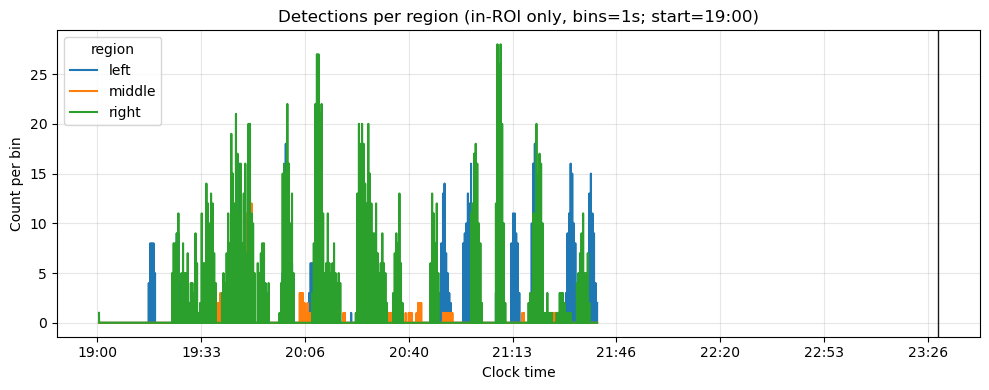

Saved figure to /Users/oakley/Documents/GitHub/signal_respirometry/figures/GX010063_2025Nov10_detections_in_roi_60s.png


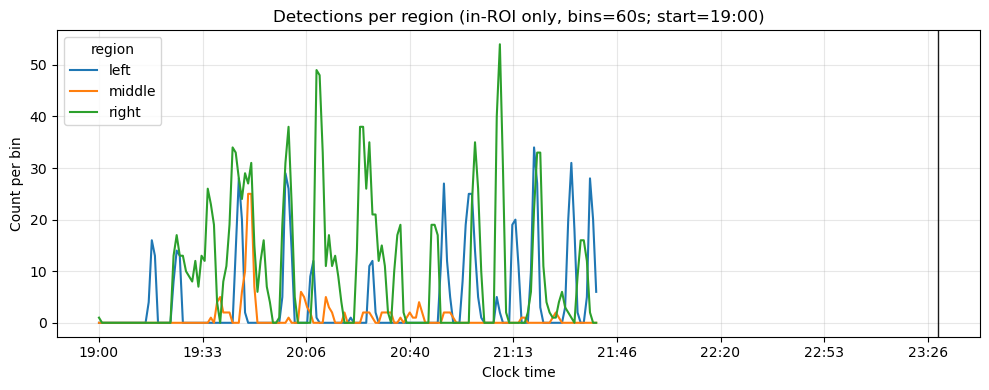

In [ ]:
# Apply ROI and persistence filtering, then write filtered detections CSV
import io, json
import pandas as pd
import numpy as np

# Inputs
csv_path      = PROCESSED_DIR / f'{Path(video_name).stem}_streaks.csv'
roi_json_path = CONFIG_DIR / f'{Path(video_name).stem}_rois.json'

# Sanity checks for required inputs
if not csv_path.exists():
    raise FileNotFoundError(f"Detections CSV not found: {csv_path}. Run the extraction cell first.")
if not roi_json_path.exists():
    available = sorted(p.name for p in CONFIG_DIR.glob('*_rois.json'))
    msg = [
        f"ROI JSON not found for {Path(video_name).stem} at {roi_json_path}.",
        "- Did you run the ROI selection cell and press ENTER to confirm?",
        f"- Expected filename: {Path(video_name).stem}_rois.json",
        f"- Available ROI files in {CONFIG_DIR}: {available if available else 'None found'}",
        "- If you want to reuse a different video's ROI, copy it to this stem or set video_name accordingly.",
    ]
    raise FileNotFoundError("\n".join(msg))

# Load detections (skip preamble)
with open(csv_path, 'r') as f:
    lines = f.readlines()
# find data header
header_idx = 0
for i, line in enumerate(lines[:100]):
    if line.lower().startswith('frame,'):
        header_idx = i
        break

df = pd.read_csv(io.StringIO(''.join(lines[header_idx:])))
print(f"Raw detections loaded: {len(df)} rows")

# Optional: filter persistent (long-lasting) contours BEFORE ROI mapping
try:
    enable_persistence_filter
except NameError:
    enable_persistence_filter = True
try:
    persistence_link_radius_px
except NameError:
    persistence_link_radius_px = 8.0   # link detections across consecutive frames within this pixel radius (scaled coords)
try:
    max_track_duration_s
except NameError:
    max_track_duration_s = 50.0       # drop tracks lasting longer than this many seconds

if enable_persistence_filter and not df.empty:
    print(f"Persistence filter ENABLED (radius={persistence_link_radius_px}, max_duration={max_track_duration_s}s)")
    df = df.sort_values(['frame']).reset_index(drop=True).copy()
    track_id_counter = -1
    assignments = np.full(len(df), -1, dtype=int)
    active = {}  # track_id -> {'last_cx','last_cy','last_frame','start_time','end_time','length'}
    frames = df['frame'].values
    times = df['time_s'].values
    cxs = df['cx'].values.astype(float)
    cys = df['cy'].values.astype(float)
    unique_frames = np.unique(frames)
    prev_frame = None
    for f in unique_frames:
        # close any track that skipped a frame
        if prev_frame is not None and f > prev_frame + 1:
            to_close = [tid for tid, t in active.items() if t['last_frame'] < f - 1]
            for tid in to_close:
                active.pop(tid, None)
        prev_frame = f
        idxs = np.where(frames == f)[0]
        used_tids = set()
        for i in idxs:
            cx, cy = cxs[i], cys[i]
            # candidates are active tracks updated on frame f-1 and within radius
            cand = []
            for tid, t in active.items():
                if t['last_frame'] == f - 1:
                    dx = cx - t['last_cx']
                    dy = cy - t['last_cy']
                    if (dx*dx + dy*dy) <= (persistence_link_radius_px * persistence_link_radius_px) and tid not in used_tids:
                        cand.append((tid, dx*dx + dy*dy))
            if cand:
                tid = min(cand, key=lambda x: x[1])[0]
                assignments[i] = tid
                t = active[tid]
                t['last_cx'] = cx; t['last_cy'] = cy; t['last_frame'] = f; t['end_time'] = times[i]; t['length'] += 1
                used_tids.add(tid)
            else:
                track_id_counter += 1
                tid = track_id_counter
                assignments[i] = tid
                active[tid] = {'last_cx': cx, 'last_cy': cy, 'last_frame': f, 'start_time': times[i], 'end_time': times[i], 'length': 1}
    # compute durations (seconds) per track
    df['track_id'] = assignments
    agg = df.groupby('track_id').agg(start_time=('time_s','min'), end_time=('time_s','max'), length=('frame','count')).reset_index()
    agg['duration_s'] = agg['end_time'] - agg['start_time']
    drop_ids = set(agg.loc[agg['duration_s'] > max_track_duration_s, 'track_id'].astype(int).tolist())
    if drop_ids:
        before = len(df)
        df = df[~df['track_id'].isin(drop_ids)].copy()
        after = len(df)
        print(f"Persistence filter: dropped {before-after} detections from {len(drop_ids)} long-lasting tracks (>{max_track_duration_s:.1f}s)")
    else:
        print("Persistence filter: no long-lasting tracks to drop.")
else:
    print("Persistence filter DISABLED")

# Determine detection coordinate scale: prefer CSV preamble, fallback to current analyze_scale/global
meta_vals = lines[1].strip().split(',') if len(lines) > 1 else []
scale_from_preamble = float(meta_vals[3]) if len(meta_vals) >= 4 else None
scale_from_global = float(globals().get('analyze_scale', 1.0))
scale_used = scale_from_preamble if scale_from_preamble is not None else scale_from_global
if scale_from_preamble is not None and 'analyze_scale' in globals():
    try:
        if abs(scale_from_preamble - float(analyze_scale)) > 1e-6:
            print(f"Warning: CSV preamble scale ({scale_from_preamble}) differs from current analyze_scale ({float(analyze_scale)}). Using preamble scale for ROI mapping.")
    except Exception:
        pass
print(f"ROI mapping scale = {scale_used} (source={'preamble' if scale_from_preamble is not None else 'global'})")

# Load ROI JSON (rects in original pixels)
with open(roi_json_path, 'r') as f:
    roi_cfg = json.load(f)
rects = roi_cfg['rects']

# Scale ROIs to detection coordinate space (scaled by scale_used)
scaled_rects = []
for r in rects:
    scaled_rects.append({
        'label': r['label'],
        'x': int(round(r['x'] * scale_used)),
        'y': int(round(r['y'] * scale_used)),
        'w': int(round(r['w'] * scale_used)),
        'h': int(round(r['h'] * scale_used)),
    })

# Assign region per detection
labels = []
for _, row in df.iterrows():
    cx, cy = float(row['cx']), float(row['cy'])
    lab = 'outside'
    for r in scaled_rects:
        if (cx >= r['x'] and cx < r['x'] + r['w'] and cy >= r['y'] and cy < r['y'] + r['h']):
            lab = r['label']
            break
    labels.append(lab)

df['region'] = labels

# Exclude 'outside' from totals and plots
df_in = df[df['region'] != 'outside'].copy()
print(f"Detections in ROI (post-filter if enabled): {len(df_in)}")

# Write filtered detections (persistence-filtered and in-ROI only) to a new CSV for downstream use
filtered_csv_path = PROCESSED_DIR / f"{Path(video_name).stem}_streaks_in_roi_filtered.csv"
# Only write the viewer-required columns, in the original order, and include the original preamble for scale
required_cols = ['frame','time_s','region','cx','cy','area','bbox_x','bbox_y','bbox_w','bbox_h']
missing_cols = [c for c in required_cols if c not in df_in.columns]
if missing_cols:
    raise ValueError(f"Filtered DataFrame missing required columns: {missing_cols}")
df_out = df_in[required_cols].copy()
# Write preamble from the raw CSV so viewers can parse scale
with open(filtered_csv_path, 'w') as out_f:
    out_f.writelines(lines[:header_idx+1])  # includes metadata lines + header row
# Append data without header to keep the original header intact
df_out.to_csv(filtered_csv_path, index=False, header=False, mode='a')
print('Wrote filtered in-ROI detections to', filtered_csv_path)

## Detection-Rate Plots (HH:MM Axis)

This step uses the filtered in-ROI detections from the prior cell and renders time-series plots with HH:MM clock labels.

In [ ]:
# Plot rates by region using HH:MM clock labels
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker as mticker

# Adjustable clock start: set as HH:MM or HH:MM:SS (e.g., '19:00', '19:15', '19:00:30')
try:
    start_clock
except NameError:
    start_clock = '19:00'

def hhmm_formatter(x, pos):
    total_seconds = float(x) + _start_offset
    hours = int((total_seconds // 3600) % 24)
    minutes = int((total_seconds % 3600) // 60)
    return f"{hours:02d}:{minutes:02d}"

def _parse_start_clock(s: str) -> int:
    parts = s.split(':')
    if len(parts) < 2:
        raise ValueError("start_clock must be 'HH:MM' or 'HH:MM:SS'")
    h = int(parts[0]) % 24
    m = int(parts[1])
    sec = int(parts[2]) if len(parts) > 2 else 0
    return h * 3600 + m * 60 + sec

_start_offset = _parse_start_clock(start_clock)

# Moonrise offset relative to start_clock, formatted as 'H:MM' or 'HH:MM' (e.g., '0:00', '0:45', '1:30')
try:
    moonrise_offset
except NameError:
    moonrise_offset = '0:00'

def _parse_hhmm_offset(s: str) -> int:
    parts = s.split(':')
    if len(parts) < 2:
        raise ValueError("moonrise_offset must be 'H:MM' or 'HH:MM'")
    h = int(parts[0])
    m = int(parts[1])
    return h * 3600 + m * 60

_moonrise_x = _parse_hhmm_offset(moonrise_offset)

if df_in.empty:
    print("No in-ROI detections to plot.")
else:
    # Totals per region (in-ROI only)
    region_totals = df_in.groupby('region').size().sort_values(ascending=False)
    print('Totals per region (in-ROI only):\n', region_totals)

    # Plot bin counts at 1s and 60s (in-ROI only) with HH:MM x-axis
    for bin_seconds in (1.0, 60.0):
        dfb = df_in.copy()
        dfb['time_bin'] = (dfb['time_s'] // bin_seconds) * bin_seconds
        counts = dfb.groupby(['region', 'time_bin']).size().reset_index(name='count')
        pivot = counts.pivot(index='time_bin', columns='region', values='count').fillna(0)
        # Build a complete time index so missing bins are zero, not absent
        if not dfb.empty:
            start_bin = float(dfb['time_bin'].min())
            end_bin = float(dfb['time_bin'].max())
            all_bins = np.arange(start_bin, end_bin + bin_seconds, bin_seconds, dtype=float)
            pivot = pivot.reindex(all_bins, fill_value=0)
        fig, ax = plt.subplots(figsize=(10, 4))
        pivot.plot(ax=ax)
        # Thin black vertical line at moonrise (relative to start)
        ax.axvline(_moonrise_x, color='k', linewidth=1.0, alpha=0.9)
        ax.set_title(f'Detections per region (in-ROI only, bins={bin_seconds:.0f}s; start={start_clock})')
        ax.set_xlabel('Clock time')
        ax.set_ylabel('Count per bin')
        # Format x-axis ticks as HH:MM based on seconds since start
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(hhmm_formatter))
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        # Save figure with video stem in figures directory
        out_path = FIGURES_DIR / f"{Path(video_name).stem}_detections_in_roi_{int(bin_seconds)}s.png"
        plt.savefig(out_path, dpi=200)
        print('Saved figure to', out_path)
        plt.show()

In [ ]:
# Final visual check: overlay ONLY in-ROI detections on the video (yellow)
# with labels of which LOI they are in
import sys, subprocess

# Prefer the filtered in-ROI, persistence-filtered CSV if available
filtered_csv = PROCESSED_DIR / f"{Path(video_name).stem}_streaks_in_roi_filtered.csv"
raw_csv      = PROCESSED_DIR / f"{Path(video_name).stem}_streaks.csv"
csv_path     = filtered_csv if filtered_csv.exists() else raw_csv

roi_json_path = CONFIG_DIR / f"{Path(video_name).stem}_rois.json"
viewer_script = SCRIPT_DIR / 'preview_contours_with_roi.py'

# Viewer options
line_thickness = 5
show_roi_edges = True   # draw ROI rectangles for context
start_frame    = 0      # change to focus on a specific segment

# Determine the correct detection/display scale for the viewer
scale_for_viewer = None
try:
    scale_for_viewer = float(analyze_scale)
except NameError:
    scale_for_viewer = None
if scale_for_viewer is None:
    # Parse from CSV preamble (filtered now includes preamble; fallback to raw CSV if needed)
    import io
    try:
        with open(csv_path, 'r') as f:
            _lines = f.readlines()
        if len(_lines) > 1:
            _vals = _lines[1].strip().split(',')
            if len(_vals) >= 4:
                scale_for_viewer = float(_vals[3])
    except Exception:
        scale_for_viewer = None
if scale_for_viewer is None:
    # Last resort
    scale_for_viewer = 1.0

cmd = [
    sys.executable,
    str(viewer_script),
    '--video', str(VIDEO_DIR / video_name),
    '--csv', str(csv_path),
    '--roi-config', str(roi_json_path),
    '--line-thickness', str(line_thickness),
    '--scale', str(scale_for_viewer),
]

if show_roi_edges:
    cmd += ['--show-roi']

print('Using CSV:', csv_path)
print('Scale for viewer:', scale_for_viewer)
print('Command:', ' '.join(cmd))
print('Controls: SPACE play/pause, LEFT/RIGHT step, R toggle ROI, Q/ESC quit')
ret = subprocess.run(cmd)
print('Exit code:', ret.returncode)

Using CSV: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010063_2025Nov10_streaks_in_roi_filtered.csv
Scale for viewer: 0.5
Command: /opt/homebrew/Caskroom/miniforge/base/envs/walle/bin/python /Users/oakley/Documents/GitHub/signal_respirometry/scripts/preview_contours_with_roi.py --video /Users/oakley/Documents/GitHub/signal_respirometry/video/GX010063_2025Nov10.MP4 --csv /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010063_2025Nov10_streaks_in_roi_filtered.csv --roi-config /Users/oakley/Documents/GitHub/signal_respirometry/data/config/GX010063_2025Nov10_rois.json --line-thickness 5 --scale 0.5 --show-roi
Controls: SPACE play/pause, LEFT/RIGHT step, R toggle ROI, Q/ESC quit
Exit code: 0
Exit code: 0


Frame 282: CSV detections=35 | recomputed_in_roi=17 of recomputed_all=26  (scale=0.5)  CSV path=GX010063_2025Nov10_streaks_in_roi_filtered.csv


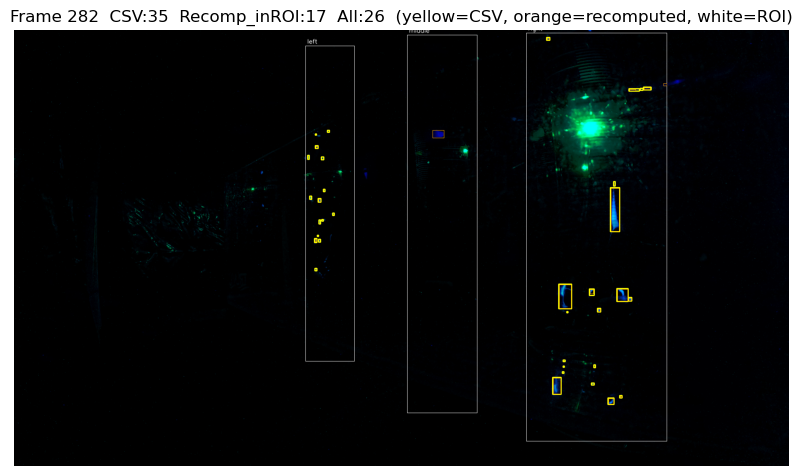

In [ ]:
# Sanity check: compare CSV detections vs recomputed contours on a single frame
import io, json, sys
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

# Settings
test_frame = int(best_frame_index) if 'best_frame_index' in globals() else 0  # change to inspect a specific frame
use_filtered = True   # True = use filtered in-ROI CSV; False = use raw CSV
recompute_only_in_roi = None  # if None, will follow use_filtered; set True/False to override

# Colors (BGR)
YELLOW = (0, 255, 255)
ORANGE = (0, 165, 255)  # easier to see than cyan against blue channel
WHITE  = (255, 255, 255)

csv_filtered = PROCESSED_DIR / f"{Path(video_name).stem}_streaks_in_roi_filtered.csv"
csv_raw = PROCESSED_DIR / f"{Path(video_name).stem}_streaks.csv"
csv_path = csv_filtered if (use_filtered and csv_filtered.exists()) else csv_raw
roi_json_path = CONFIG_DIR / f"{Path(video_name).stem}_rois.json"

# Load CSV and parse scale from preamble
with open(csv_path, 'r') as f:
    lines = f.readlines()
header_idx = 0
for i, line in enumerate(lines[:200]):
    if line.lower().startswith('frame,'):
        header_idx = i
        break
df = pd.read_csv(io.StringIO(''.join(lines[header_idx:])))
meta_vals = lines[1].strip().split(',') if len(lines) > 1 else []
scale_used = float(meta_vals[3]) if len(meta_vals) >= 4 else float(globals().get('analyze_scale', 1.0))

# Load ROI and scale
with open(roi_json_path, 'r') as f:
    roi_cfg = json.load(f)
rects = roi_cfg.get('rects', [])
scaled_rois = [{
    'label': r['label'],
    'x': int(round(r['x'] * scale_used)),
    'y': int(round(r['y'] * scale_used)),
    'w': int(round(r['w'] * scale_used)),
    'h': int(round(r['h'] * scale_used)),
} for r in rects]

# Helper: check ROI intersection for a bbox
def _bbox_intersects_any_roi(x, y, w, h, rois):
    if not rois:
        return False
    x2, y2 = x + w, y + h
    for r in rois:
        rx2, ry2 = r['x'] + r['w'], r['y'] + r['h']
        if (x < rx2) and (x2 > r['x']) and (y < ry2) and (y2 > r['y']):
            return True
    return False

# Open video and seek
cap = cv2.VideoCapture(str(VIDEO_DIR / video_name))
if not cap.isOpened():
    raise RuntimeError(f'Cannot open video: {VIDEO_DIR / video_name}')
cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, int(test_frame)))
ok, frame = cap.read()
cap.release()
if not ok:
    raise RuntimeError(f'Failed to read frame {test_frame}')

# Prepare display frame to detection scale and zero red (so overlays stand out)
disp = frame
if scale_used != 1.0:
    disp = cv2.resize(disp, None, fx=scale_used, fy=scale_used, interpolation=cv2.INTER_AREA)
disp = disp.copy()
disp[:, :, 2] = 0

# Draw ROI rectangles for context
for r in scaled_rois:
    cv2.rectangle(disp, (r['x'], r['y']), (r['x'] + r['w'], r['y'] + r['h']), WHITE, 1)
    cv2.putText(disp, r['label'], (r['x'] + 4, max(0, r['y'] - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, WHITE, 1, cv2.LINE_AA)

# Get CSV detections for this frame
rows = df[df['frame'] == int(test_frame)] if 'frame' in df.columns else pd.DataFrame()
csv_count = len(rows)

# Draw CSV detections in yellow
for _, row in rows.iterrows():
    x, y, w, h = int(row['bbox_x']), int(row['bbox_y']), int(row['bbox_w']), int(row['bbox_h'])
    if w > 0 and h > 0:
        cv2.rectangle(disp, (x, y), (x + w, y + h), YELLOW, 2)
    else:
        cx, cy = int(round(float(row['cx']))), int(round(float(row['cy'])))
        cv2.drawMarker(disp, (cx, cy), YELLOW, markerType=cv2.MARKER_CROSS, markerSize=8, thickness=2)

# Optionally recompute contours on this frame for comparison (orange)
def _threshold_blue(img_bgr, blue_thresh=None, blur_ksize=0, use_bminusg=True):
    if use_bminusg:
        blue = img_bgr[:, :, 0].astype(np.int16)
        green = img_bgr[:, :, 1].astype(np.int16)
        target = np.clip(blue - green, 0, 255).astype(np.uint8)
    else:
        target = img_bgr[:, :, 0]
    if blur_ksize and int(blur_ksize) > 0:
        k = int(blur_ksize) if int(blur_ksize) % 2 == 1 else int(blur_ksize) + 1
        target = cv2.GaussianBlur(target, (k, k), 0)
    if blue_thresh is None or str(blue_thresh).lower() == 'none':
        _, bw = cv2.threshold(target, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    else:
        _, bw = cv2.threshold(target, int(blue_thresh), 255, cv2.THRESH_BINARY)
    return bw

try:
    bt = globals().get('blue_thresh', None)
    bk = int(globals().get('blur_ksize', 0))
    uma = bool(globals().get('use_bminusg', True))
    ma = float(globals().get('min_area', 1.5))
except Exception:
    bt, bk, uma, ma = None, 0, True, 1.5

if recompute_only_in_roi is None:
    recompute_only_in_roi = bool(use_filtered)

bw = _threshold_blue(disp.copy(), blue_thresh=bt, blur_ksize=bk, use_bminusg=uma)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
clean = cv2.morphologyEx(bw, cv2.MORPH_OPEN, kernel, iterations=1)
contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

recomp_all = []
recomp_in_roi = []
for c in contours:
    area = cv2.contourArea(c)
    if area >= ma:
        x, y, w, h = cv2.boundingRect(c)
        recomp_all.append((x, y, w, h))
        if _bbox_intersects_any_roi(x, y, w, h, scaled_rois):
            recomp_in_roi.append((x, y, w, h))

# Choose which recomputed boxes to draw
boxes_to_draw = recomp_in_roi if recompute_only_in_roi else recomp_all
for (x, y, w, h) in boxes_to_draw:
    cv2.rectangle(disp, (x, y), (x + w, y + h), ORANGE, 1)

print(
    f"Frame {test_frame}: "
    f"CSV detections={csv_count} | "
    f"recomputed_in_roi={len(recomp_in_roi)} of recomputed_all={len(recomp_all)}  "
    f"(scale={scale_used})  CSV path={csv_path.name}"
)

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(disp, cv2.COLOR_BGR2RGB))
legend_note = 'yellow=CSV, orange=recomputed, white=ROI'
plt.title(f'Frame {test_frame}  CSV:{csv_count}  Recomp_inROI:{len(recomp_in_roi)}  All:{len(recomp_all)}  ({legend_note})')
plt.axis('off')
plt.show()

### Empirically determined duration threshold to remove persistent contours

Raw detections: 4398 rows
     track_id roi_label  len_rows  duration_s
2           2   outside       337     10080.0
1           1    middle       337     10080.0
0           0   outside       261      7800.0
3           3   outside        73      2160.0
812       812   outside        72      2130.0
836       836   outside        62      1830.0
909       909   outside        47      1380.0
134       134   outside        41      1200.0
916       916     right        36      1050.0
928       928   outside        35      1020.0
     track_id roi_label  len_rows  duration_s
2           2   outside       337     10080.0
1           1    middle       337     10080.0
0           0   outside       261      7800.0
3           3   outside        73      2160.0
812       812   outside        72      2130.0
836       836   outside        62      1830.0
909       909   outside        47      1380.0
134       134   outside        41      1200.0
916       916     right        36      1050.0
928     

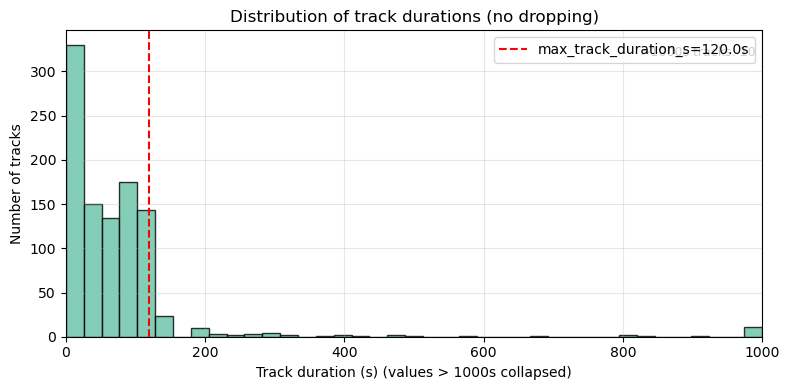

Duration quantiles (s): {0.5: 60.0, 0.75: 90.0, 0.9: 120.0, 0.95: 150.0, 0.99: 988.2}
Tracks above 1000s: 10 (max=10080.0s)


In [ ]:
# Track duration analysis (no dropping): histogram and top tracks (tail >1000s collapsed)
import io, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raw_csv = PROCESSED_DIR / f"{Path(video_name).stem}_streaks.csv"
roi_json_path = CONFIG_DIR / f"{Path(video_name).stem}_rois.json"

# Load raw detections
with open(raw_csv, 'r') as f:
    lines = f.readlines()
header_idx = 0
for i, line in enumerate(lines[:200]):
    if line.lower().startswith('frame,'):
        header_idx = i
        break
raw_df = pd.read_csv(io.StringIO(''.join(lines[header_idx:])))
print(f"Raw detections: {len(raw_df)} rows")

# Scale from preamble
meta_vals = lines[1].strip().split(',') if len(lines) > 1 else []
scale_used = float(meta_vals[3]) if len(meta_vals) >= 4 else float(globals().get('analyze_scale', 1.0))

# Link radius and params
link_radius = float(globals().get('persistence_link_radius_px', 8.0))

# Rebuild tracks without dropping
raw_df = raw_df.sort_values(['frame']).reset_index(drop=True).copy()
frames = raw_df['frame'].values
cxs = raw_df['cx'].values.astype(float)
cys = raw_df['cy'].values.astype(float)
times = raw_df['time_s'].values.astype(float)
assignments = np.full(len(raw_df), -1, dtype=int)
active = {}
track_id_counter = -1
prev_frame = None
for f in np.unique(frames):
    if prev_frame is not None and f > prev_frame + 1:
        # close tracks that missed a frame
        to_close = [tid for tid, t in active.items() if t['last_frame'] < f - 1]
        for tid in to_close:
            active.pop(tid, None)
    prev_frame = f
    idxs = np.where(frames == f)[0]
    used_tids = set()
    for i in idxs:
        cx, cy = cxs[i], cys[i]
        # candidates active at f-1
        cand = []
        for tid, t in active.items():
            if t['last_frame'] == f - 1:
                dx = cx - t['last_cx']
                dy = cy - t['last_cy']
                if (dx*dx + dy*dy) <= (link_radius * link_radius) and tid not in used_tids:
                    cand.append((tid, dx*dx + dy*dy))
        if cand:
            tid = min(cand, key=lambda x: x[1])[0]
            assignments[i] = tid
            t = active[tid]
            t['last_cx'] = cx; t['last_cy'] = cy; t['last_frame'] = f; t['end_time'] = times[i]; t['length'] += 1
            used_tids.add(tid)
        else:
            track_id_counter += 1
            tid = track_id_counter
            assignments[i] = tid
            active[tid] = {'last_cx': cx, 'last_cy': cy, 'last_frame': f, 'start_time': times[i], 'end_time': times[i], 'length': 1}

raw_df['track_id'] = assignments
agg = raw_df.groupby('track_id').agg(start_time=('time_s','min'), end_time=('time_s','max'), start_frame=('frame','min'), end_frame=('frame','max'), len_rows=('frame','count')).reset_index()
agg['duration_s'] = agg['end_time'] - agg['start_time']

# ROI majority label per track (diagnostic)
with open(roi_json_path, 'r') as f:
    roi_cfg = json.load(f)
rects = roi_cfg['rects']
scaled_rois = [{
    'label': r['label'],
    'x': int(round(r['x'] * scale_used)),
    'y': int(round(r['y'] * scale_used)),
    'w': int(round(r['w'] * scale_used)),
    'h': int(round(r['h'] * scale_used)),
} for r in rects]

def _label_point(cx, cy):
    lab = 'outside'
    for r in scaled_rois:
        if (cx >= r['x'] and cx < r['x'] + r['w'] and cy >= r['y'] and cy < r['y'] + r['h']):
            lab = r['label']
            break
    return lab

raw_df['roi_label'] = [ _label_point(float(cx), float(cy)) for cx, cy in zip(raw_df['cx'], raw_df['cy']) ]
maj = raw_df.groupby(['track_id','roi_label']).size().rename('n').reset_index()
maj = maj.sort_values(['track_id','n'], ascending=[True, False])
maj = maj.loc[maj.groupby('track_id')['n'].idxmax()][['track_id','roi_label']]
agg = agg.merge(maj, on='track_id', how='left')

# Print summary top tracks
print(agg[['track_id','roi_label','len_rows','duration_s']].sort_values('duration_s', ascending=False).head(10))

try:
    current_thresh = float(globals().get('max_track_duration_s', 50.0))
except Exception:
    current_thresh = 50.0

# Histogram with tail collapsing
tail_threshold = 1000.0
max_dur = agg['duration_s'].max()
if max_dur <= tail_threshold:
    # Standard plot
    durations_for_plot = agg['duration_s'].values
    bins = 40
    tail_count = 0
else:
    durations_for_plot = np.clip(agg['duration_s'].values, None, tail_threshold)
    tail_count = int(np.sum(agg['duration_s'].values > tail_threshold))
    # Use fixed bin edges from 0 to tail_threshold
    bins = np.linspace(0, tail_threshold, 40)

fig, ax = plt.subplots(figsize=(8,4))
ax.hist(durations_for_plot, bins=bins, color='#66c2a5', edgecolor='k', alpha=0.8)
ax.axvline(current_thresh, color='r', linestyle='--', label=f'max_track_duration_s={current_thresh:.1f}s')
if max_dur > tail_threshold:
    ax.text(0.99, 0.95, f">{int(tail_threshold)}s tracks: {tail_count}", transform=ax.transAxes, ha='right', va='top', fontsize=9, bbox={'facecolor':'white','alpha':0.7,'edgecolor':'none'})
    ax.set_xlim(0, tail_threshold)
    ax.set_xlabel(f'Track duration (s) (values > {int(tail_threshold)}s collapsed)')
else:
    ax.set_xlabel('Track duration (s)')
ax.set_ylabel('Number of tracks')
ax.set_title('Distribution of track durations (no dropping)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Quantiles (computed on original durations)
qs = agg['duration_s'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]).to_dict()
print('Duration quantiles (s):', {k: round(v,2) for k,v in qs.items()})
if max_dur > tail_threshold:
    print(f"Tracks above {tail_threshold:.0f}s: {tail_count} (max={max_dur:.1f}s)")

In [75]:
# What-if sweep: impact of different max_track_duration_s thresholds
import numpy as np
import pandas as pd

# Reuse agg from previous cell if available; else reconstruct minimal version
try:
    agg
    raw_df
except NameError:
    raise RuntimeError('Run the Track duration analysis cell first.')

# Build list of thresholds to test (seconds)
base = float(globals().get('max_track_duration_s', 50.0))
ths = sorted(set([10, 15, 20, 30, 40, 50, 60, 90, base]))

# For each threshold, drop detections from tracks whose duration exceeds threshold
results = []
for t in ths:
    drop_ids = set(agg.loc[agg['duration_s'] > t, 'track_id'].astype(int).tolist())
    kept = raw_df[~raw_df['track_id'].isin(drop_ids)].copy()
    # If roi_label not present on kept rows, re-merge
    if 'roi_label' not in kept.columns:
        kept = kept.merge(agg[['track_id','roi_label']], on='track_id', how='left')
    totals_by_roi = kept.loc[kept['roi_label'] != 'outside'].groupby('roi_label').size().sort_values(ascending=False)
    results.append({
        'threshold_s': t,
        'rows_kept': int(len(kept)),
        'rows_dropped': int(len(raw_df) - len(kept)),
        'unique_tracks_dropped': int(len(drop_ids)),
        'roi_totals': totals_by_roi.to_dict(),
    })

res_df = pd.DataFrame([{
    'threshold_s': r['threshold_s'],
    'rows_kept': r['rows_kept'],
    'rows_dropped': r['rows_dropped'],
    'unique_tracks_dropped': r['unique_tracks_dropped'],
    **{f"roi_{k}": v for k, v in r['roi_totals'].items()}
} for r in results]).sort_values('threshold_s')

print('What-if sweep results:')
print(res_df.fillna(0).to_string(index=False))

# Simple recommendation: choose threshold at ~95th percentile of durations (bounded by sweep grid)
q95 = float(agg['duration_s'].quantile(0.95))
recommended = min(ths, key=lambda t: abs(t - q95))
print(f"\nSuggested threshold near 95th percentile: ~{q95:.1f}s (nearest tested = {recommended}s)")

What-if sweep results:
 threshold_s  rows_kept  rows_dropped  unique_tracks_dropped  roi_right  roi_left  roi_middle
        10.0        330          4068                    673        268        32          12
        15.0        330          4068                    673        268        32          12
        20.0        330          4068                    673        268        32          12
        30.0        630          3768                    523        468        70          24
        40.0        630          3768                    523        468        70          24
        50.0        630          3768                    523        468        70          24
        60.0       1032          3366                    389        660       187          66
        90.0       1732          2666                    214        976       491         110
       120.0       2447          1951                     71       1482       626         125

Suggested threshold near 95th percen

Diagnostics: raw_all_rows=4398, raw_in_roi_rows=2877, filtered_rows=2233
Middle ROI label guessed: middle; longest consecutive raw in-ROI run = 337 frames


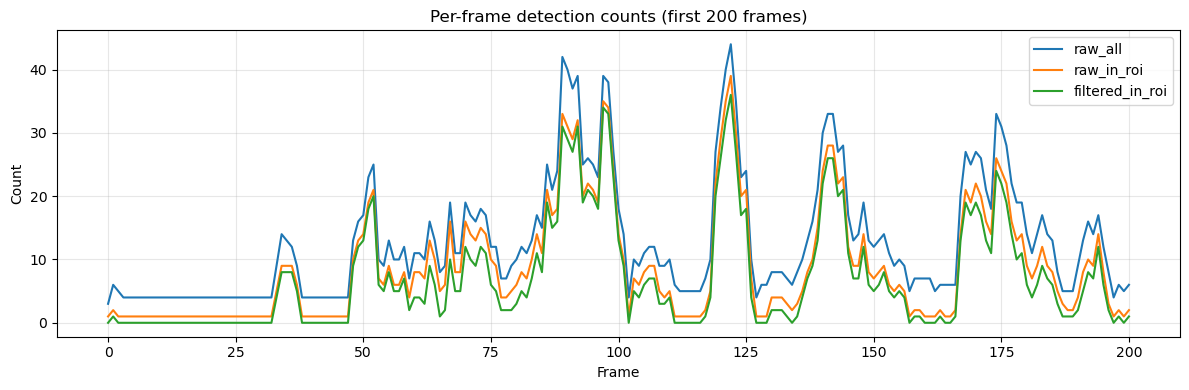

       raw_all  raw_in_roi  filtered_in_roi
frame                                      
0            3           1                0
1            6           2                1
2            5           1                0
3            4           1                0
4            4           1                0
5            4           1                0
6            4           1                0
7            4           1                0
8            4           1                0
9            4           1                0
10           4           1                0
11           4           1                0
12           4           1                0
13           4           1                0
14           4           1                0
15           4           1                0
16           4           1                0
17           4           1                0
18           4           1                0
19           4           1                0


In [ ]:
# Diagnostics: per-frame counts raw vs in-ROI (no persistence) vs filtered CSV
import io, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

raw_csv = PROCESSED_DIR / f"{Path(video_name).stem}_streaks.csv"
filtered_csv = PROCESSED_DIR / f"{Path(video_name).stem}_streaks_in_roi_filtered.csv"
roi_json_path = CONFIG_DIR / f"{Path(video_name).stem}_rois.json"

if not raw_csv.exists():
    raise FileNotFoundError(raw_csv)
if not roi_json_path.exists():
    raise FileNotFoundError(roi_json_path)

# Load raw CSV (skip preamble)
with open(raw_csv, 'r') as f:
    lines = f.readlines()
header_idx = 0
for i, line in enumerate(lines[:200]):
    if line.lower().startswith('frame,'):
        header_idx = i
        break
raw_df = pd.read_csv(io.StringIO(''.join(lines[header_idx:])))

# Parse scale
meta_vals = lines[1].strip().split(',') if len(lines) > 1 else []
scale_used = float(meta_vals[3]) if len(meta_vals) >= 4 else float(globals().get('analyze_scale', 1.0))

# Load ROIs
with open(roi_json_path, 'r') as f:
    roi_cfg = json.load(f)
rects = roi_cfg['rects']
scaled_rois = [{
    'label': r['label'],
    'x': int(round(r['x'] * scale_used)),
    'y': int(round(r['y'] * scale_used)),
    'w': int(round(r['w'] * scale_used)),
    'h': int(round(r['h'] * scale_used)),
} for r in rects]

# Assign region WITHOUT any persistence filtering (diagnostic baseline)
labels = []
for _, row in raw_df.iterrows():
    cx, cy = float(row['cx']), float(row['cy'])
    lab = 'outside'
    for r in scaled_rois:
        if (cx >= r['x'] and cx < r['x'] + r['w'] and cy >= r['y'] and cy < r['y'] + r['h']):
            lab = r['label']
            break
    labels.append(lab)
raw_df['region_diag'] = labels
raw_in_roi = raw_df[raw_df['region_diag'] != 'outside'].copy()

# Load filtered CSV if present
if filtered_csv.exists():
    with open(filtered_csv, 'r') as f:
        filt_lines = f.readlines()
    filt_header_idx = 0
    for i, line in enumerate(filt_lines[:200]):
        if line.lower().startswith('frame,'):
            filt_header_idx = i
            break
    filtered_df = pd.read_csv(io.StringIO(''.join(filt_lines[filt_header_idx:])))
else:
    filtered_df = pd.DataFrame(columns=['frame'])

# Per-frame counts
raw_all_counts = raw_df.groupby('frame').size().rename('raw_all')
raw_in_counts = raw_in_roi.groupby('frame').size().rename('raw_in_roi')
filt_counts = filtered_df.groupby('frame').size().rename('filtered_in_roi') if not filtered_df.empty else pd.Series(dtype=int, name='filtered_in_roi')

counts = pd.concat([raw_all_counts, raw_in_counts, filt_counts], axis=1).fillna(0).astype(int)

# Identify continuous streaks for a chosen ROI label (middle ROI heuristic: pick ROI with median area)
roi_areas = [(r['label'], r['w']*r['h']) for r in scaled_rois]
roi_areas.sort(key=lambda x: x[1])
if roi_areas:
    middle_label = roi_areas[len(roi_areas)//2][0]
else:
    middle_label = None

if middle_label:
    mid_mask = raw_in_roi['region_diag'] == middle_label
    mid_frames = sorted(raw_in_roi.loc[mid_mask, 'frame'].unique().tolist())
    # Compute longest consecutive run
    longest_run = 0
    current = 0
    prev = None
    for f in mid_frames:
        if prev is None or f == prev + 1:
            current += 1
        else:
            longest_run = max(longest_run, current)
            current = 1
        prev = f
    longest_run = max(longest_run, current)
else:
    longest_run = 0

print(f"Diagnostics: raw_all_rows={len(raw_df)}, raw_in_roi_rows={len(raw_in_roi)}, filtered_rows={len(filtered_df)}")
if middle_label:
    print(f"Middle ROI label guessed: {middle_label}; longest consecutive raw in-ROI run = {longest_run} frames")

# Plot comparisons for first 200 frames (adjust as needed)
max_frames_to_show = 200
sub = counts[counts.index <= max_frames_to_show]
fig, ax = plt.subplots(figsize=(12,4))
sub[['raw_all','raw_in_roi','filtered_in_roi']].plot(ax=ax)
ax.set_title(f'Per-frame detection counts (first {max_frames_to_show} frames)')
ax.set_xlabel('Frame')
ax.set_ylabel('Count')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Show a small table sample
print(sub.head(20))